## 13.4 实战案例37：使用分类策略预测英伟达股票走势

### 13.4.1 步骤1： 数据准备和处理

In [25]:

import pandas as pd
# 数据准备和处理
df = pd.read_csv('data/HistoricalData_NVIDIA(5年).csv')

# 将“Date”列转换为日期格式，注意这里指定了日期格式为'%m/%d/%Y'
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# 确保日期按升序排列
df = df.sort_values(by='Date')
# 清洗数据
df['Close/Last'] = df['Close/Last'].str.replace('$', '').astype(float)
df['Open'] = df['Open'].str.replace('$', '').astype(float)
df['High'] = df['High'].str.replace('$', '').astype(float)
df['Low'] = df['Low'].str.replace('$', '').astype(float)
df #打印df

,Date,Close/Last,Volume,Open,High,Low
1256,2020-02-26,6.6913,749661600,6.5515,6.8863,6.5500
1255,2020-02-27,6.3150,906414800,6.3725,6.6750,6.2222
1254,2020-02-28,6.7518,1134675200,6.0614,6.8115,6.0448
1253,2020-03-02,6.9108,890745600,6.9225,6.9398,6.5250
1252,2020-03-03,6.6472,652793200,6.9667,7.0267,6.5615
...,...,...,...,...,...,...
4,2025-02-19,139.2300,167536000,139.5100,141.3600,137.2200
3,2025-02-20,140.1100,143903600,140.0300,140.6600,136.7901
2,2025-02-21,134.4300,228217600,140.0400,141.4600,134.0300
1,2025-02-24,130.2800,251381100,136.5600,138.5900,130.0800


#### 13.4.2 步骤2：模型训练

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import joblib
# 创建标签列
df['Label'] = df['Close/Last'].diff().gt(0).astype(int)

# 提取特征和目标变量
X = df[['Volume', 'Open', 'High', 'Low']]
y = df['Label']

# 划分训练集测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 构建Pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
# 模型训练
pipe.fit(X_train, y_train)
# 保存模型
joblib.dump(pipe, 'nvidia_classification_mode .pkl')
# 测试集预测
y_pred = pipe.predict(X_test)
# 准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy}")

df

准确率: 0.5661375661375662


,Date,Close/Last,Volume,Open,High,Low,Label
1256,2020-02-26,6.6913,749661600,6.5515,6.8863,6.5500,0
1255,2020-02-27,6.3150,906414800,6.3725,6.6750,6.2222,0
1254,2020-02-28,6.7518,1134675200,6.0614,6.8115,6.0448,1
1253,2020-03-02,6.9108,890745600,6.9225,6.9398,6.5250,1
1252,2020-03-03,6.6472,652793200,6.9667,7.0267,6.5615,0
...,...,...,...,...,...,...,...
4,2025-02-19,139.2300,167536000,139.5100,141.3600,137.2200,0
3,2025-02-20,140.1100,143903600,140.0300,140.6600,136.7901,1
2,2025-02-21,134.4300,228217600,140.0400,141.4600,134.0300,0
1,2025-02-24,130.2800,251381100,136.5600,138.5900,130.0800,0


#### 步骤4：使用DeepSeek进行优化模型

In [6]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# 创建Logistic回归模型
log_reg = LogisticRegression()

# 定义参数网格，设置需要调节的超参数值
param_grid = {
    'model__C': [0.1, 1, 10, 100],  # 正则化参数C，越大正则化越弱
    'model__solver': ['liblinear', 'saga'],  # 求解器，liblinear适合小数据集，saga适合大数据集
    'model__penalty': ['l1', 'l2']  # 正则化方式，l1是Lasso，l2是Ridge
}
# 创建Pipeline，将预处理步骤与模型训练结合
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # 用均值填补缺失值
    ('scaler', StandardScaler()),  # 对特征进行标准化处理
    ('model', log_reg)  # 使用Logistic回归模型
])

# 设置网格搜索，使用5折交叉验证，评分方式为准确率
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', verbose=1)

# 训练模型
grid_search.fit(X_train, y_train)
# 输出最佳超参数
print("最佳超参数组合: ", grid_search.best_params_)
# 输出最佳的交叉验证准确率
print("最佳交叉验证得分: ", grid_search.best_score_)
# 使用最佳模型进行预测
best_model = grid_search.best_estimator_
# 在测试集上评估
y_pred = best_model.predict(X_test)
# 输出测试集准确率
print("测试集准确率: ", accuracy_score(y_test, y_pred))
# 保存训练好的模型到文件
joblib.dump(best_model, 'nvidia_classification_model.pkl')
print("模型已保存为 'nvidia_classification_model.pkl'")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

最佳超参数组合:  {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
最佳交叉验证得分:  0.747487012987013
测试集准确率:  0.7936507936507936
模型已保存为 'nvidia_classification_model.pkl'


c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### 步骤5：预测股票走势

In [28]:
import pandas as pd
import joblib

# 加载模型
loaded_model = joblib.load('nvidia_classification_model.pkl')

# 新数据准备
new_data = pd.read_csv('data/HistoricalData_NVIDIA.csv')

# 确保 'Close/Last' 列为字符串类型，然后替换掉美元符号并转换为浮动数值
new_data['Close/Last'] = new_data['Close/Last'].astype(str).str.replace('$', '').astype(float)
new_data['Open'] = new_data['Open'].astype(str).str.replace('$', '').astype(float)
new_data['High'] = new_data['High'].astype(str).str.replace('$', '').astype(float)
new_data['Low'] = new_data['Low'].astype(str).str.replace('$', '').astype(float)

# 保存原始的 'Close/Last' 和 'Date' 列，以便后续使用
close_last_column = new_data['Close/Last']
date_column = new_data['Date']

# 删除 'Close/Last' 和 'Date' 列
new_data.drop('Close/Last', axis=1, inplace=True)
new_data.drop('Date', axis=1, inplace=True)

# 预测结果
predicted_labels = loaded_model.predict(new_data)

# 将预测结果加入原始数据中
new_data['Predicted_Label'] = predicted_labels

# 输出预测结果，重新加入 'Close/Last' 和 'Date' 列
result = new_data[['Predicted_Label']]
result['Close/Last'] = close_last_column
result['Date'] = date_column
# 输出结果
result

C:\Users\tonyg\AppData\Local\Temp\ipykernel_32004\1008800533.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Close/Last'] = close_last_column
C:\Users\tonyg\AppData\Local\Temp\ipykernel_32004\1008800533.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Date'] = date_column


,Predicted_Label,Close/Last,Date
0,0,139.40,02/18/2025
1,1,138.85,02/14/2025
2,1,135.29,02/13/2025
3,1,131.14,02/12/2025
4,1,132.80,02/11/2025
5,1,133.57,02/10/2025
6,0,129.84,02/07/2025
7,0,128.68,02/06/2025
8,1,124.83,02/05/2025
9,1,118.65,02/04/2025


## 13.5 实战案例38：使用回归策略预测英伟达股票走势

### 13.5.1 步骤1： 数据准备和处理

In [21]:
import pandas as pd
# 数据准备和处理
df = pd.read_csv('data/HistoricalData_NVIDIA(5年).csv')

# 将“Date”列转换为日期格式，注意这里指定了日期格式为'%m/%d/%Y'
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# 确保日期按升序排列
df = df.sort_values(by='Date')
# 清洗数据
df['Close/Last'] = df['Close/Last'].str.replace('$', '').astype(float)
df['Open'] = df['Open'].str.replace('$', '').astype(float)
df['High'] = df['High'].str.replace('$', '').astype(float)
df['Low'] = df['Low'].str.replace('$', '').astype(float)
df #打印df

,Date,Close/Last,Volume,Open,High,Low
1256,2020-02-26,6.6913,749661600,6.5515,6.8863,6.5500
1255,2020-02-27,6.3150,906414800,6.3725,6.6750,6.2222
1254,2020-02-28,6.7518,1134675200,6.0614,6.8115,6.0448
1253,2020-03-02,6.9108,890745600,6.9225,6.9398,6.5250
1252,2020-03-03,6.6472,652793200,6.9667,7.0267,6.5615
...,...,...,...,...,...,...
4,2025-02-19,139.2300,167536000,139.5100,141.3600,137.2200
3,2025-02-20,140.1100,143903600,140.0300,140.6600,136.7901
2,2025-02-21,134.4300,228217600,140.0400,141.4600,134.0300
1,2025-02-24,130.2800,251381100,136.5600,138.5900,130.0800


### 13.5.2 步骤2：模型训练

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib


# 提取特征和目标变量
X = df[['Volume', 'Open', 'High', 'Low']]	
y = df['Close/Last']

# 划分训练集测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 2. 模型训练
model = LinearRegression()	
model.fit(X_train, y_train)
# 3. 测试集预测
y_pred = model.predict(X_test)	
# 4. 模型评估
mse = mean_squared_error(y_test, y_pred)
print(f"均方误差 (MSE): {mse}")

# 保存模型数据
joblib.dump(model, 'nvidia_regression_model.pkl')

均方误差 (MSE): 0.39966257011019735


['nvidia_regression_model.pkl']

### 13.5.3 步骤3：预测股票走势

In [56]:


import pandas as pd
import joblib

# 加载训练好的模型
model = joblib.load('nvidia_regression_model.pkl')

# 2. 加载新的股票数据
new_data = pd.read_csv('data/HistoricalData_NVIDIA.csv') 

# 将“Date”列转换为日期格式，注意这里指定了日期格式为'%m/%d/%Y'
new_data['Date'] = pd.to_datetime(new_data['Date'], format='%m/%d/%Y')

# 确保日期按升序排列
new_data = new_data.sort_values(by='Date')

# 清洗数据
new_data['Close/Last'] = new_data['Close/Last'].str.replace('$', '').astype(float)
new_data['Open'] = new_data['Open'].str.replace('$', '').astype(float)
new_data['High'] = new_data['High'].str.replace('$', '').astype(float)
new_data['Low'] = new_data['Low'].str.replace('$', '').astype(float)

# 提取新数据的特征
X_new = new_data[['Volume', 'Open', 'High', 'Low']]  # 使用与训练数据相同的特征

# 使用训练好的模型进行预测
predicted_close = model.predict(X_new)

# 将预测结果加入到新的数据框
new_data['Predicted_Price'] = predicted_close

# 5. 输出预测结果
print("股票价格预测结果：")
new_data[['Date', 'Close/Last', 'Predicted_Price']]

股票价格预测结果：


,Date,Close/Last,Predicted_Price
19,2025-01-21,140.83,140.009871
18,2025-01-22,147.07,146.843021
17,2025-01-23,147.22,146.133060
16,2025-01-24,142.62,143.688896
15,2025-01-27,118.42,121.232806
14,2025-01-28,128.99,123.469030
13,2025-01-29,123.70,121.618676
12,2025-01-30,124.65,120.738994
11,2025-01-31,120.07,123.619712
10,2025-02-03,116.66,116.799089


##### 13.5.5 步骤5：使用DeepSeek进行优化模型

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib

# 计算RSI的函数
def compute_RSI(series, period=14):
    delta = series.diff()  # 计算连续日的差值
    gain = (delta.where(delta > 0, 0))  # 涨幅
    loss = (-delta.where(delta < 0, 0))  # 跌幅

    avg_gain = gain.rolling(window=period, min_periods=1).mean()  # 14日内的平均涨幅
    avg_loss = loss.rolling(window=period, min_periods=1).mean()  # 14日内的平均跌幅

    rs = avg_gain / avg_loss  # 相对强弱值
    rsi = 100 - (100 / (1 + rs))  # RSI计算公式

    return rsi

# 数据准备和处理
df = pd.read_csv('data/HistoricalData_NVIDIA(5年).csv')
df['Close/Last'] = df['Close/Last'].str.replace('$', '').astype(float)
df['Open'] = df['Open'].str.replace('$', '').astype(float)
df['High'] = df['High'].str.replace('$', '').astype(float)
df['Low'] = df['Low'].str.replace('$', '').astype(float)

# 增加特征
df['Prev_Close'] = df['Close/Last'].shift(1)  # 前一天的收盘价
df['Price_Range'] = df['High'] - df['Low']  # 价格波动
df['Price_Change'] = (df['Close/Last'] - df['Prev_Close']) / df['Prev_Close']  # 涨跌幅
df['Volume_MA'] = df['Volume'].rolling(window=5).mean()  # 5日成交量均值
df['SMA_5'] = df['Close/Last'].rolling(window=5).mean()  # 5日简单移动平均
df['RSI_14'] = compute_RSI(df['Close/Last'], 14)  # 14日相对强弱指数

# 删除缺失值
df = df.dropna()

# 提取特征和目标变量
X = df[['Volume', 'Open', 'High', 'Low', 'Price_Range', 'Price_Change', 'Volume_MA', 'SMA_5', 'RSI_14']]  # 增加特征
y = df['Close/Last']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 模型训练
model = LinearRegression()
model.fit(X_train, y_train)

# 测试集预测
y_pred = model.predict(X_test)

# 模型评估
mse = mean_squared_error(y_test, y_pred)
print(f"均方误差 (MSE): {mse}")

# 保存模型数据
joblib.dump(model, 'nvidia_regression_model_optimized.pkl')


均方误差 (MSE): 0.30355850805979234


['nvidia_regression_model_optimized.pkl']

#### 步骤6：使用优化后的模型再次预测股票走势

In [61]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# 计算RSI的函数
def compute_RSI(series, period=14):
    delta = series.diff()  # 计算连续日的差值
    gain = (delta.where(delta > 0, 0))  # 涨幅
    loss = (-delta.where(delta < 0, 0))  # 跌幅

    avg_gain = gain.rolling(window=period, min_periods=1).mean()  # 14日内的平均涨幅
    avg_loss = loss.rolling(window=period, min_periods=1).mean()  # 14日内的平均跌幅

    rs = avg_gain / avg_loss  # 相对强弱值
    rsi = 100 - (100 / (1 + rs))  # RSI计算公式

    return rsi

# 1. 加载训练好的模型
model = joblib.load('nvidia_regression_model_optimized.pkl')
# 2. 加载新的股票数据
df_new = pd.read_csv('data/HistoricalData_NVIDIA.csv') 

# 将“Date”列转换为日期格式，注意这里指定了日期格式为'%m/%d/%Y'
df_new['Date'] = pd.to_datetime(df_new['Date'], format='%m/%d/%Y')
# 确保日期按升序排列
df_new = df_new.sort_values(by='Date')
# 清洗数据
df_new['Close/Last'] = df_new['Close/Last'].str.replace('$', '').astype(float)
df_new['Open'] = df_new['Open'].str.replace('$', '').astype(float)
df_new['High'] = df_new['High'].str.replace('$', '').astype(float)
df_new['Low'] = df_new['Low'].str.replace('$', '').astype(float)

# 增加特征
df_new['Prev_Close'] = df_new['Close/Last'].shift(1)  # 前一天的收盘价
df_new['Price_Range'] = df_new['High'] - df_new['Low']  # 价格波动
df_new['Price_Change'] = (df_new['Close/Last'] - df_new['Prev_Close']) / df_new['Prev_Close']  # 涨跌幅
df_new['Volume_MA'] = df_new['Volume'].rolling(window=5).mean()  # 5日成交量均值
df_new['SMA_5'] = df_new['Close/Last'].rolling(window=5).mean()  # 5日简单移动平均
df_new['RSI_14'] = compute_RSI(df_new['Close/Last'], 14)  # 14日相对强弱指数

# 删除缺失值
df_new = df_new.dropna()

# 提取特征
X_new = df_new[['Volume', 'Open', 'High', 'Low', 'Price_Range', 'Price_Change', 'Volume_MA', 'SMA_5', 'RSI_14']]

# 4. 使用模型进行预测
y_pred_new = model.predict(X_new)

# 将预测结果加入原数据框
df_new['Predicted_Price'] = y_pred_new

# 5. 输出预测结果
print("股票价格预测结果：")
df_new[['Date', 'Close/Last', 'Predicted_Price']]

股票价格预测结果：


,Date,Close/Last,Predicted_Price
15,2025-01-27,118.42,122.525513
14,2025-01-28,128.99,125.321841
13,2025-01-29,123.70,122.640842
12,2025-01-30,124.65,121.508398
11,2025-01-31,120.07,123.264605
10,2025-02-03,116.66,117.226315
9,2025-02-04,118.65,120.519719
8,2025-02-05,124.83,123.643496
7,2025-02-06,128.68,126.344285
6,2025-02-07,129.84,126.442661


## 13.6 实战案例39：LSTM神经网络预测比特币价格趋势

### 13.6.4 步骤1：加载和清洗数据

In [5]:
import pandas as pd
# 读取数据
df = pd.read_csv('data/比特币历史数据（5年）.csv',encoding='utf-8')

# 数据准备和处理
# 转换日期列为datetime类型
df['日期'] = pd.to_datetime(df['日期'], format='%Y-%m-%d')  # 根据实际日期格式调整

# 确保日期按升序排列
df = df.sort_values(by='日期')
# 打印排序后的数据
df.head(10)

,日期,收盘,开盘,高,低,交易量,涨跌幅
1513,2021-01-06,"36,793.2","33,999.3","36,934.8","33,408.3",227.56K,8.24%
1512,2021-01-07,"39,460.2","36,798.5","40,340.9","36,361.2",249.60K,7.25%
1511,2021-01-08,"40,599.3","39,466.4","41,921.7","36,613.4",251.29K,2.89%
1510,2021-01-09,"40,151.9","40,607.2","41,363.5","38,775.1",128.42K,-1.10%
1509,2021-01-10,"38,192.2","40,149.7","41,362.4","35,141.6",215.78K,-4.88%
1508,2021-01-11,"35,544.3","38,195.3","38,217.2","30,411.6",251.04K,-6.93%
1507,2021-01-12,"34,076.1","35,426.0","36,598.7","32,572.7",241.93K,-4.13%
1506,2021-01-13,"37,382.2","34,061.2","37,764.6","32,451.9",209.93K,9.70%
1505,2021-01-14,"39,175.7","37,383.4","40,054.3","36,772.1",172.40K,4.80%
1504,2021-01-15,"36,845.8","39,175.7","39,715.0","34,488.7",118.42K,-5.95%


#### 2.清洗数据

In [6]:
# 将字符串转换浮点类型
df['收盘'] = df['收盘'].str.replace(',', '').astype(float)
# 打印排序后的数据
df.head(10)

,日期,收盘,开盘,高,低,交易量,涨跌幅
1513,2021-01-06,36793.2,"33,999.3","36,934.8","33,408.3",227.56K,8.24%
1512,2021-01-07,39460.2,"36,798.5","40,340.9","36,361.2",249.60K,7.25%
1511,2021-01-08,40599.3,"39,466.4","41,921.7","36,613.4",251.29K,2.89%
1510,2021-01-09,40151.9,"40,607.2","41,363.5","38,775.1",128.42K,-1.10%
1509,2021-01-10,38192.2,"40,149.7","41,362.4","35,141.6",215.78K,-4.88%
1508,2021-01-11,35544.3,"38,195.3","38,217.2","30,411.6",251.04K,-6.93%
1507,2021-01-12,34076.1,"35,426.0","36,598.7","32,572.7",241.93K,-4.13%
1506,2021-01-13,37382.2,"34,061.2","37,764.6","32,451.9",209.93K,9.70%
1505,2021-01-14,39175.7,"37,383.4","40,054.3","36,772.1",172.40K,4.80%
1504,2021-01-15,36845.8,"39,175.7","39,715.0","34,488.7",118.42K,-5.95%


### 13.6.5 步骤2：模型训练

In [9]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

# 提取收盘价数据
closing_prices = df['收盘'].values.reshape(-1, 1)  # 将收盘价数据转换为二维数组

# 数据预处理
scaler = MinMaxScaler(feature_range=(0, 1))  # 初始化归一化器，将数据缩放到 [0, 1] 范围
scaled_prices = scaler.fit_transform(closing_prices)  # 对收盘价数据进行归一化

# 划分训练集和测试集
train_size = int(len(scaled_prices) * 0.8)  # 计算训练集大小，占总数据的 80%
train_data = scaled_prices[:train_size]  # 提取训练集数据
test_data = scaled_prices[train_size:]  # 提取测试集数据

# 构建训练集和测试集
def create_dataset(data, time_steps=1):
    """
    将时间序列数据转换为模型所需的输入格式
    :param data: 归一化后的时间序列数据
    :param time_steps: 时间步长，默认为 1
    :return: 输入特征 X 和目标值 Y
    """
    X, Y = [], []
    for i in range(len(data) - time_steps):  # 遍历数据，生成样本
        X.append(data[i:(i + time_steps), 0])  # 提取时间步长内的数据作为输入特征
        Y.append(data[i + time_steps, 0])  # 提取下一个时间点的数据作为目标值
    return np.array(X), np.array(Y)  # 转换为 NumPy 数组

time_steps = 10  # 设置时间步长为 10
X_train, y_train = create_dataset(train_data, time_steps)  # 生成训练集数据
X_test, y_test = create_dataset(test_data, time_steps)  # 生成测试集数据

# 调整输入数据形状
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # 调整为 LSTM 输入形状 (样本数, 时间步长, 特征数)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))  # 调整测试集输入形状

# 构建LSTM模型
model = Sequential()  # 初始化顺序模型
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))  # 添加第一层 LSTM，50 个单元，返回完整序列
model.add(LSTM(units=50))  # 添加第二层 LSTM，50 个单元
model.add(Dense(units=1))  # 添加全连接层，输出一个值
model.compile(optimizer='adam', loss='mean_squared_error')  # 编译模型，使用 Adam 优化器和均方误差损失函数

# 训练模型
model.fit(X_train, y_train, epochs=10, batch_size=32)  # 训练模型，10 轮训练，批量大小为 32

# 保存模型
model.save("bitcoin_prediction_model.keras")  # 将模型保存为文件
print("模型已保存为 bitcoin_prediction_model.keras")  # 打印保存成功信息

# 模型评估
# 使用模型对测试集进行预测
predicted_prices = model.predict(X_test)  # 对测试集进行预测
# 计算测试集上的损失函数值
test_loss = model.evaluate(X_test, y_test)  # 计算模型在测试集上的损失
print("测试集上的损失函数值：", test_loss)  # 打印损失函数值



Epoch 1/10


c:\users\tonyg\appdata\local\programs\python\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0288
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0672e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4404e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4295e-04
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3229e-04
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.8707e-04
模型已保存为 bitcoin_prediction_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013      
测试集上的损失函数值： 0.0016765777254477143


### 13.6.6 步骤3：可视化结果

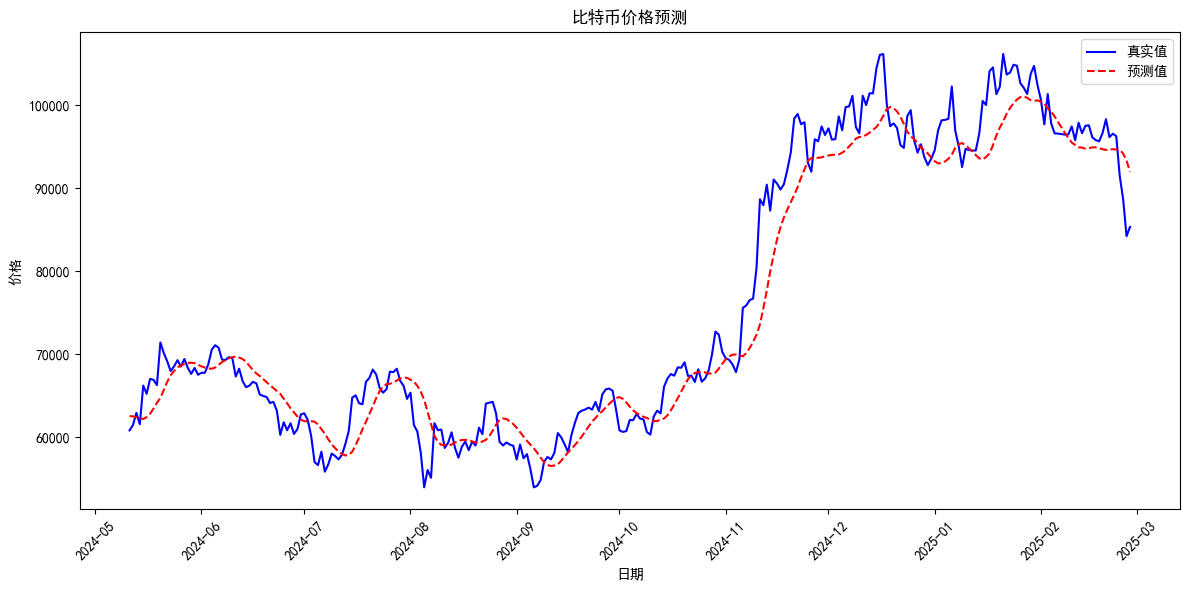

In [10]:
import matplotlib.pyplot as plt

# 设置中文字体和解决负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体，解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题，确保负号正常显示

# 反归一化
predicted_prices = scaler.inverse_transform(predicted_prices)  # 将预测值反归一化，转换为实际价格
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))  # 将测试集真实值反归一化，转换为实际价格

# 创建图表
plt.figure(figsize=(12, 6))  # 设置图表大小为 12x6

# 绘制真实值曲线
plt.plot(
    df['日期'].iloc[len(df) - len(y_test):].values,  # 提取测试集对应的日期
    y_test_actual,  # 真实值数据
    label='真实值',  # 图例标签
    color='blue'  # 曲线颜色为蓝色
)

# 绘制预测值曲线
plt.plot(
    df['日期'].iloc[len(df) - len(y_test):].values,  # 提取测试集对应的日期
    predicted_prices,  # 预测值数据
    label='预测值',  # 图例标签
    color='red',  # 曲线颜色为红色
    linestyle='--'  # 曲线样式为虚线
)

# 设置图表标题和坐标轴标签
plt.title('比特币价格预测')  # 图表标题
plt.xlabel('日期')  # X 轴标签
plt.ylabel('价格')  # Y 轴标签

# 显示图例
plt.legend()  # 显示图例，标识真实值和预测值

# 调整日期标签的旋转角度
plt.xticks(rotation=45)  # 将 X 轴日期标签旋转 45 度，避免重叠

# 自动调整图表布局
plt.tight_layout()  # 确保图表元素不会超出画布范围

# 显示图表
plt.show()  # 显示绘制的图表

### 13.6.7 步骤4：使用DeepSeek进行模型评估

In [12]:
# 模型评估
# 使用模型对测试集进行预测
predicted_prices = model.predict(X_test)

# 计算测试集上的损失函数值
test_loss = model.evaluate(X_test, y_test)

print("测试集上的损失函数值：", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013     
测试集上的损失函数值： 0.0016765777254477143


### 步骤6比特币价格预测

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
预测价格结果：
日期: 2025-01-29T00:00:00.000000000, 预测价格: 100107.59
日期: 2025-01-30T00:00:00.000000000, 预测价格: 100010.34
日期: 2025-01-31T00:00:00.000000000, 预测价格: 100057.80
日期: 2025-02-01T00:00:00.000000000, 预测价格: 99990.37
日期: 2025-02-02T00:00:00.000000000, 预测价格: 99735.12
日期: 2025-02-03T00:00:00.000000000, 预测价格: 99163.59
日期: 2025-02-04T00:00:00.000000000, 预测价格: 98775.97
日期: 2025-02-05T00:00:00.000000000, 预测价格: 98211.41
日期: 2025-02-06T00:00:00.000000000, 预测价格: 97522.28
日期: 2025-02-07T00:00:00.000000000, 预测价格: 96823.39
日期: 2025-02-08T00:00:00.000000000, 预测价格: 96172.62
日期: 2025-02-09T00:00:00.000000000, 预测价格: 95599.80
日期: 2025-02-10T00:00:00.000000000, 预测价格: 95123.04
日期: 2025-02-11T00:00:00.000000000, 预测价格: 94820.79
日期: 2025-02-12T00:00:00.000000000, 预测价格: 94506.13
日期: 2025-02-13T00:00:00.000000000, 预测价格: 94392.07
日期: 2025-02-14T00:00:00.000000000, 预测价格: 94289.35
日期: 2025-02-15T00:00:00.000000000, 预测价格: 94283.09
日期: 2025-02-16T00:00:00.000000000, 预测价格: 94333.94


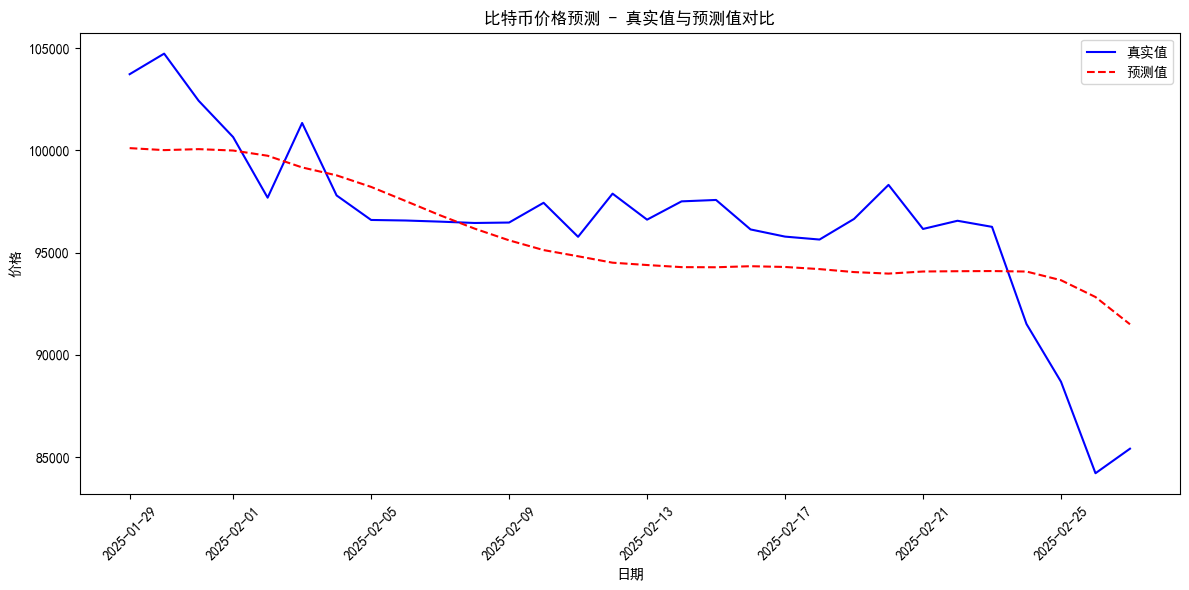

In [47]:
import numpy as np
import pandas as pd
from keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# 读取数据
df = pd.read_csv('data/比特币历史数据 （6个月）.csv', encoding='utf-8')  # 从 CSV 文件中读取比特币历史数据，指定编码为 utf-8

# 数据准备和处理
# 转换日期列为datetime类型
df['日期'] = pd.to_datetime(df['日期'], format='%Y-%m-%d')  # 将日期列转换为 datetime 类型，指定日期格式

# 确保日期按升序排列
df = df.sort_values(by='日期')  # 按日期升序排列数据
# 将字符串转换浮点类型
df['收盘'] = df['收盘'].str.replace(',', '').astype(float)  # 将收盘价列中的逗号移除，并转换为浮点数类型
# 选择收盘价作为目标变量
closing_prices = df['收盘'].values.reshape(-1, 1)  # 提取收盘价数据并转换为二维数组

# 数据归一化
scaler = MinMaxScaler(feature_range=(0, 1))  # 初始化归一化器，将数据缩放到 [0, 1] 范围
scaled_prices = scaler.fit_transform(closing_prices)  # 对收盘价数据进行归一化

# 创建时间序列数据集
def create_dataset(data, time_step=60):
    """
    将时间序列数据转换为模型所需的输入格式
    :param data: 归一化后的时间序列数据
    :param time_step: 时间步长，默认为 60
    :return: 输入特征 X 和目标值 y
    """
    X, y = [], []
    for i in range(len(data) - time_step):  # 遍历数据，生成样本
        X.append(data[i:i + time_step, 0])  # 提取时间步长内的数据作为输入特征
        y.append(data[i + time_step, 0])  # 提取下一个时间点的数据作为目标值
    return np.array(X), np.array(y)  # 转换为 NumPy 数组

# 设置时间步长
time_step = 60  # 设置时间步长为 60

# 生成完整数据集
X, y = create_dataset(scaled_prices, time_step)  # 生成完整的时间序列数据集
# 获取测试数据集（使用最后30天数据）
X_test, y_test = create_dataset(scaled_prices[-(30 + time_step):], time_step)  # 使用最后 30 天的数据生成测试集

# 检查数据是否有效
if len(X_test) == 0:
    raise ValueError("测试集数据不足，无法生成样本！请减少时间步长或增加数据量。")  # 如果测试集为空，抛出错误提示

# LSTM 输入形状调整
X_test = X_test.reshape(-1, time_step, 1)  # 将测试集调整为 LSTM 模型所需的输入形状 (样本数, 时间步长, 特征数)

# 加载已经训练好的模型
model = load_model('bitcoin_prediction_model.keras')  # 加载已训练好的 LSTM 模型

# 预测测试集数据
predicted_prices = model.predict(X_test)  # 使用模型对测试集进行预测，得到归一化的预测结果
predicted_prices = scaler.inverse_transform(predicted_prices)  # 将预测结果反归一化，转换为实际价格值

# 获取对应的日期
dates = df['日期'].iloc[-len(y_test):].values  # 提取测试集对应的日期

# 打印预测结果
print("预测价格结果：")
for date, price in zip(dates, predicted_prices):
    print(f"日期: {date}, 预测价格: {price[0]:.2f}")

# 获取真实值
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))  # 将测试集真实值反归一化，转换为实际价格值

# 可视化结果
import matplotlib.pyplot as plt

# 设置中文字体和解决负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体，解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题，确保负号正常显示

plt.figure(figsize=(12, 6))  # 设置图表大小为 12x6
plt.plot(dates, real_prices, label='真实值', color='blue')  # 绘制真实值曲线，颜色为蓝色
plt.plot(dates, predicted_prices, label='预测值', color='red', linestyle='--')  # 绘制预测值曲线，颜色为红色，线型为虚线
plt.title('比特币价格预测 - 真实值与预测值对比')  # 设置图表标题
plt.xlabel('日期')  # 设置 X 轴标签
plt.ylabel('价格')  # 设置 Y 轴标签
plt.legend()  # 显示图例，标识真实值和预测值
plt.xticks(rotation=45)  # 将 X 轴日期标签旋转 45 度，避免重叠
plt.tight_layout()  # 自动调整图表布局，确保图表元素不会超出画布范围
plt.show()  # 显示绘制的图表